11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9213 - loss: 0.2761 - val_accuracy: 0.9642 - val_loss: 0.1313
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9644 - loss: 0.1210 - val_accuracy: 0.9737 - val_loss: 0.0891
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9750 - loss: 0.0825 - val_accuracy: 0.9767 - val_loss: 0.0882
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9814 - loss: 0.0615 - val_accuracy: 0.9772 - val_loss: 0.0801
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9864 - loss: 0.0453 - val_accuracy: 0.9792 - val_loss: 0.0786
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0774
Test accuracy: 0.9754999876022339
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


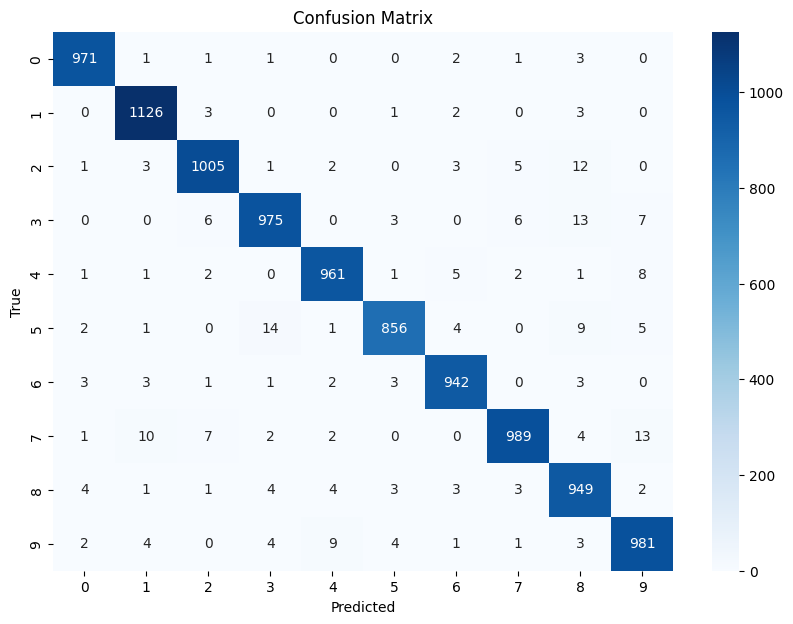

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



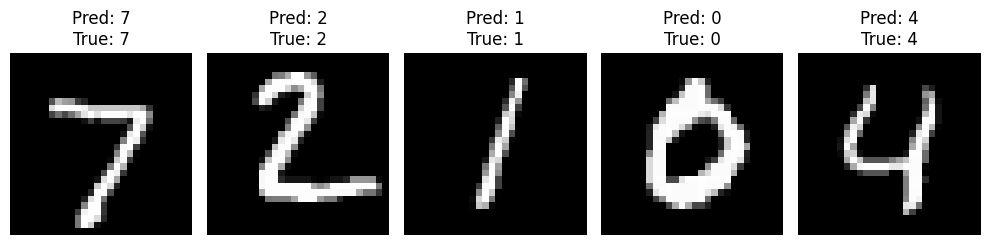

In [1]:

# -*- coding: utf-8 -*-
# TensorFlow: Класифікація рукописних цифр (MNIST)

import tensorflow as tf
from tensorflow.keras import datasets, models, layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Завантаження даних MNIST
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# 2. Нормалізація
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Побудова моделі
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Компіляція та навчання
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 5. Оцінка точності
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# 6. Передбачення
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 9. Візуалізація прикладів
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [2]:
# === ЕКСПЕРИМЕНТ: Покращена модель ===

# 1. Побудова покращеної моделі (більше шарів + Dropout)
model_v2 = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2. Компіляція
model_v2.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 3. Навчання (більше епох)
history_v2 = model_v2.fit(x_train, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9005 - loss: 0.3223 - val_accuracy: 0.9702 - val_loss: 0.1018
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9527 - loss: 0.1580 - val_accuracy: 0.9732 - val_loss: 0.0872
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9631 - loss: 0.1218 - val_accuracy: 0.9773 - val_loss: 0.0725
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9670 - loss: 0.1055 - val_accuracy: 0.9775 - val_loss: 0.0729
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9719 - loss: 0.0918 - val_accuracy: 0.9795 - val_loss: 0.0667
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9743 - loss: 0.0833 - val_accuracy: 0.9790 - val_loss: 0.0701
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9760 - loss: 0.0759 - val_accuracy: 0.9807 - val_loss: 0.0656
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9781 - loss: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9805 - loss: 0.0675
Базова модель — Test accuracy: 0.9755
Покращена модель — Test accuracy: 0.9805
Різниця: +0.50%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


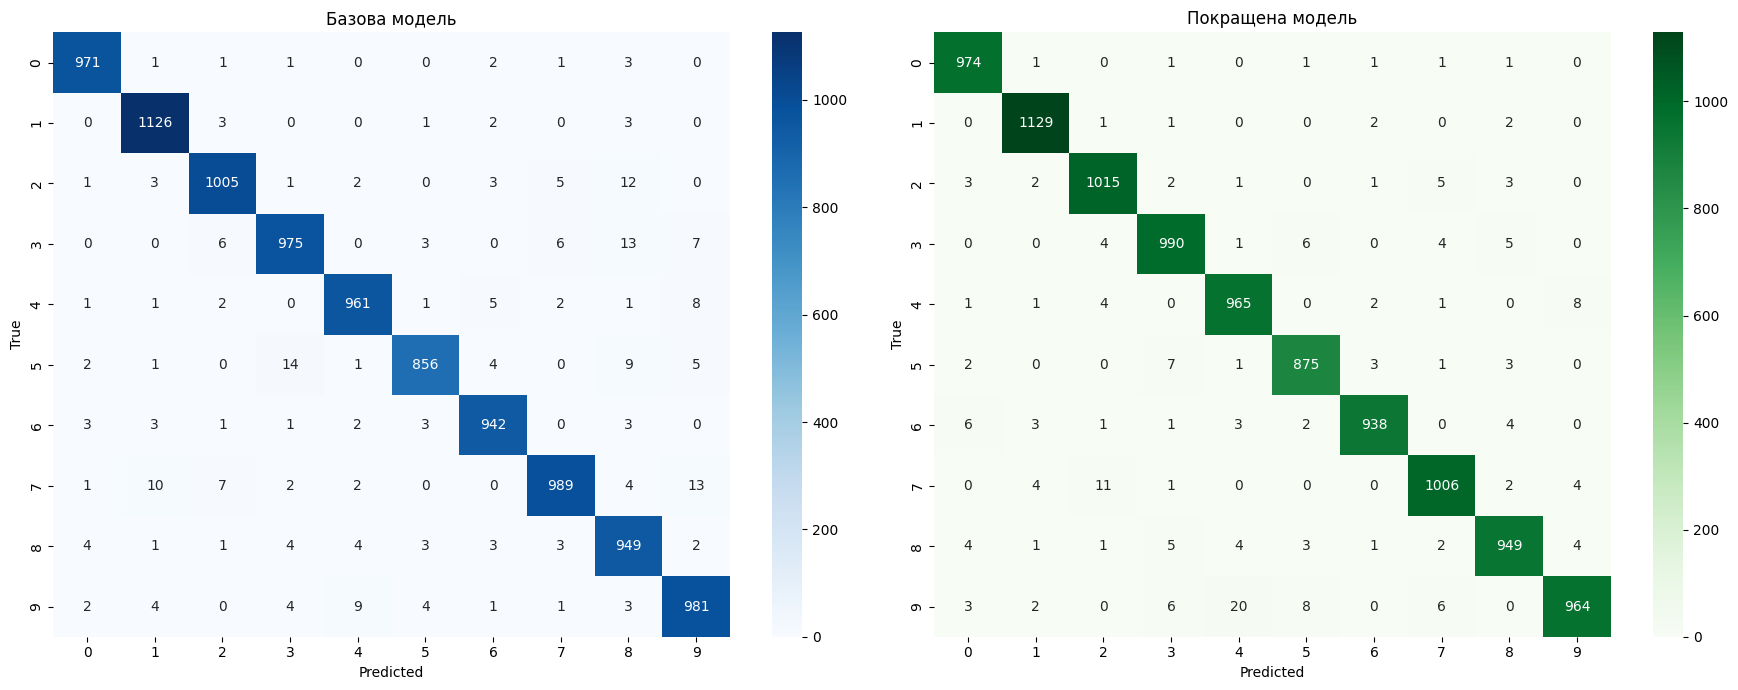


=== Classification Report (Покращена модель) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [3]:
# === ОЦІНКА ПОКРАЩЕНОЇ МОДЕЛІ ===

# 1. Точність на тестовій вибірці
test_loss_v2, test_acc_v2 = model_v2.evaluate(x_test, y_test)
print(f"Базова модель — Test accuracy: {test_acc:.4f}")
print(f"Покращена модель — Test accuracy: {test_acc_v2:.4f}")
print(f"Різниця: {(test_acc_v2 - test_acc)*100:+.2f}%")

# 2. Передбачення
predictions_v2 = model_v2.predict(x_test)
y_pred_v2 = np.argmax(predictions_v2, axis=1)

# 3. Confusion Matrix
cm_v2 = confusion_matrix(y_test, y_pred_v2)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Базова модель')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Покращена модель')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# 4. Classification Report
print("\n=== Classification Report (Покращена модель) ===")
print(classification_report(y_test, y_pred_v2))

In [4]:
# === ЗБЕРЕЖЕННЯ ТА ЗАВАНТАЖЕННЯ МОДЕЛІ ===

# 1. Збереження покращеної моделі
model_v2.save("mnist_model_v2.keras")
print("Модель збережено у файл 'mnist_model_v2.keras'")

# 2. Завантаження моделі
loaded_model = tf.keras.models.load_model("mnist_model_v2.keras")
print("Модель завантажено")

# 3. Перевірка: чи завантажена модель дає такі ж результати?
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test)
print(f"\nТочність збереженої моделі: {loaded_acc:.4f}")
print(f"Точність до збереження:     {test_acc_v2:.4f}")
print(f"Результати ідентичні: {abs(loaded_acc - test_acc_v2) < 1e-6}")

Модель збережено у файл 'mnist_model_v2.keras'
Модель завантажено
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9805 - loss: 0.0675

Точність збереженої моделі: 0.9805
Точність до збереження:     0.9805
Результати ідентичні: True


Кількість помилок: 195 з 10000 (1.9%)


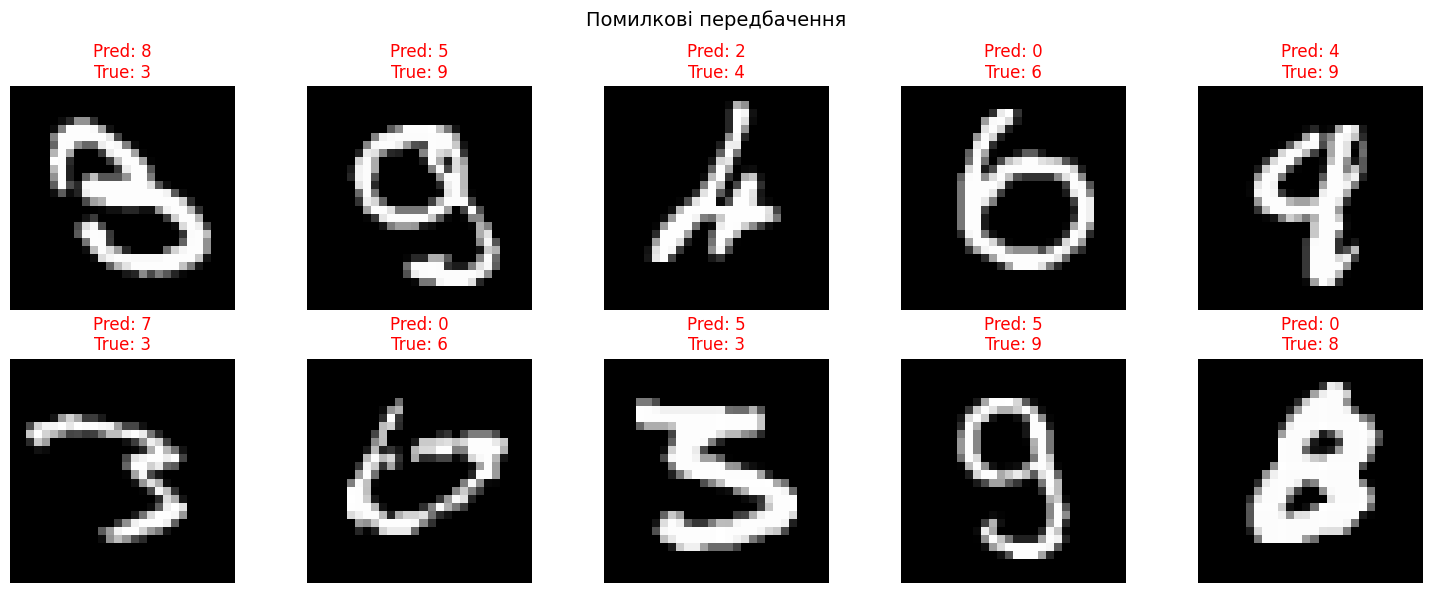

In [5]:
# === ВІЗУАЛІЗАЦІЯ ПОМИЛКОВИХ ПЕРЕДБАЧЕНЬ ===

errors = np.where(y_pred_v2 != y_test)[0]
print(f"Кількість помилок: {len(errors)} з {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")

plt.figure(figsize=(15, 6))
for i in range(min(10, len(errors))):
    idx = errors[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Pred: {y_pred_v2[idx]}\nTrue: {y_test[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Помилкові передбачення", fontsize=14)
plt.tight_layout()
plt.show()

# **TensorFlow**
Тема: Класифікація рукописних цифр (MNIST) із простою багатошаровою нейронною мережею
Мета: Ознайомитися з основними концепціями TensorFlow (тензори, шари, оптимізатор, функція втрат) на прикладі простої задачі класифікації зображень.

**Завдання**  (те, що дано і треба розібратись)

Навчання моделі на датасеті MNIST

Завантажте MNIST (використавши вбудовані методи tensorflow.keras.datasets або інші доступні джерела).

Створіть просту нейронну мережу (мінімум один прихований шар, наприклад, Dense(128, activation='relu')) у tf.keras.Sequential.
Оцінка моделі (evaluate)

Виведіть точність (accuracy) на тестовій вибірці за допомогою model.evaluate(...).

Побудуйте Confusion Matrix, скориставшись пакетом sklearn.metrics.confusion_matrix.

Виведіть Classification Report (precision, recall, f1-score) через sklearn.metrics.classification_report.

Візуалізація прикладів

Виведіть щонайменше 5 зображень із тестового набору (matplotlib.pyplot.imshow(...)).

Для кожного зображення вкажіть передбачений клас (argmax) та істинну мітку (y_test).

Обговоріть, чи трапляються помилки, і як вони виглядають.

**Додаткові експерименти** **(те, що треба виконати)**

Змініть кількість шарів або змінні параметри (наприклад, додайте ще один Dense чи збільште кількість епох).

Збережіть або завантажте модель (model.save("mnist_model.h5"), model.load_model(...)) і перевірте, чи результат зберігається.

Оцініть, як це впливає на Confusion Matrix, Classification Report та точність.

**Оформлення результатів** **(те, що треба виконати)**

У звіті:
Опишіть архітектуру моделі (кількість шарів, кількість нейронів).

Наведіть (скриншоти чи вивід) Confusion Matrix та Classification Report.

Покажіть декілька прикладів зображень із правильним або помилковим передбаченням.

Підготуйте **висновки**: на яких цифрах модель помиляється найчастіше, яка загальна точність, чи покращились результати після змін у мережі тощо.

